In [36]:
!pip install networkx pandas matplotlib seaborn --quiet

import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import random
from matplotlib import cm
from matplotlib.colors import Normalize
from IPython.display import display

# For reproducibility
RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

Edges Sheet (connections):


,Source,Target
0,School,Market
1,School,Gandhi street
2,Market,Gandhi street
3,Market,Temple street
4,Gandhi street,DABC


Areas Sheet (node attributes):


,Label,DogDensity,VaccinationRate
0,School,5,0.4
1,Market,25,0.1
2,Gandhi street,15,0.3
3,Temple street,10,0.5
4,DABC,8,0.7



✅ Graph built successfully: 5 nodes, 7 edges


,Node,DogDensity,VaccinationRate
0,School,5.0,0.4
1,Market,25.0,0.1
2,Gandhi street,15.0,0.3
3,Temple street,10.0,0.5
4,DABC,8.0,0.7


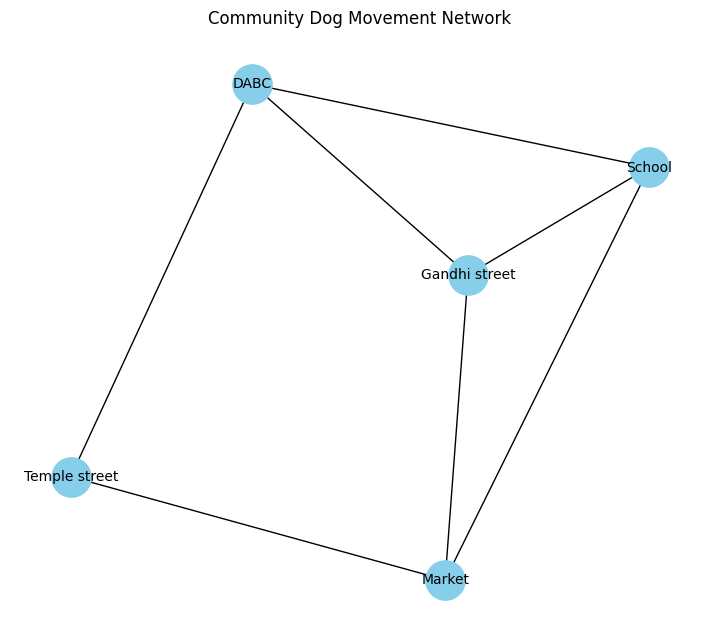

In [37]:
# Your Google Sheet ID
sheet_id = "1-4wnG1-tg4J5K8svat6W6CqLcKG64a1mmADvF91K5ec"

# Load both tabs separately
edges = pd.read_csv(f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet=edges")
areas = pd.read_csv(f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet=Areas")

print("Edges Sheet (connections):")
display(edges.head())

print("Areas Sheet (node attributes):")
display(areas.head())

# Column mapping
SRC_COL, TGT_COL = "Source", "Target"
LABEL_COL, DENS_COL, VACC_COL = "Label", "DogDensity", "VaccinationRate"

# --- Build Undirected Graph ---
G = nx.Graph()

# Add all areas first
for _, row in areas.iterrows():
    label = str(row[LABEL_COL])
    G.add_node(label)
    G.nodes[label][DENS_COL] = float(row[DENS_COL])
    G.nodes[label][VACC_COL] = float(row[VACC_COL])

# Add edges between connected areas
for _, row in edges.iterrows():
    src, tgt = str(row[SRC_COL]), str(row[TGT_COL])
    if src in G.nodes() and tgt in G.nodes():
        G.add_edge(src, tgt)

print(f"\n✅ Graph built successfully: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Node table
nodes_df = pd.DataFrame([
    {"Node": n, DENS_COL: G.nodes[n][DENS_COL], VACC_COL: G.nodes[n][VACC_COL]}
    for n in G.nodes()
])
display(nodes_df)

# Plot graph
# Draw the graph (correct version)
plt.figure(figsize=(7,6))
pos = nx.spring_layout(G, seed=RNG_SEED)
nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=800, font_size=10)
plt.title("Community Dog Movement Network")
plt.show()

Enter the starting infected area (as in 'Label' column): Market
BFS Ranking (Shortest Reachable Areas):


,Node,Distance
0,Market,0
1,School,1
2,Gandhi street,1
3,Temple street,1
4,DABC,2


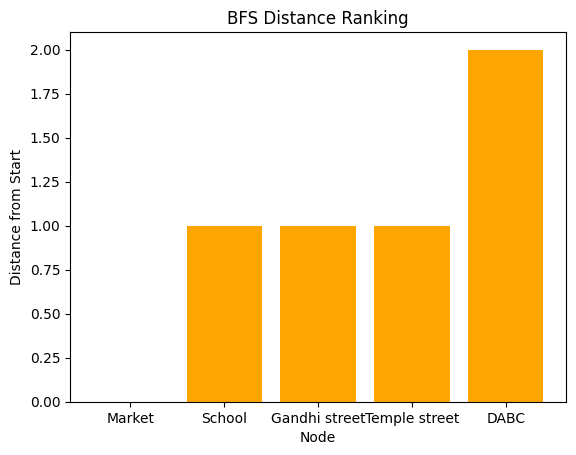

In [38]:
def bfs_ranking(G, start):
    visited = set([start])
    queue = deque([(start, 0)])
    distances = {start: 0}
    while queue:
        node, dist = queue.popleft()
        for nb in G.neighbors(node):
            if nb not in visited:
                visited.add(nb)
                distances[nb] = dist + 1
                queue.append((nb, dist + 1))
    return sorted(distances.items(), key=lambda x: x[1])

start_node = input("Enter the starting infected area (as in 'Label' column): ").strip()

if start_node not in G.nodes:
    raise ValueError(f"'{start_node}' not found in graph nodes. Check the spelling or case.")

bfs_result = bfs_ranking(G, start_node)
bfs_df = pd.DataFrame(bfs_result, columns=["Node", "Distance"])
print("BFS Ranking (Shortest Reachable Areas):")
display(bfs_df)

# Plot
plt.bar(bfs_df["Node"], bfs_df["Distance"], color="orange")
plt.title("BFS Distance Ranking")
plt.xlabel("Node")
plt.ylabel("Distance from Start")
plt.show()

A* Ranking (High Density + Low Vaccination → High Risk):


,Node,Risk Score
0,Gandhi street,10.5
1,Temple street,5.0
2,School,3.0
3,DABC,2.4


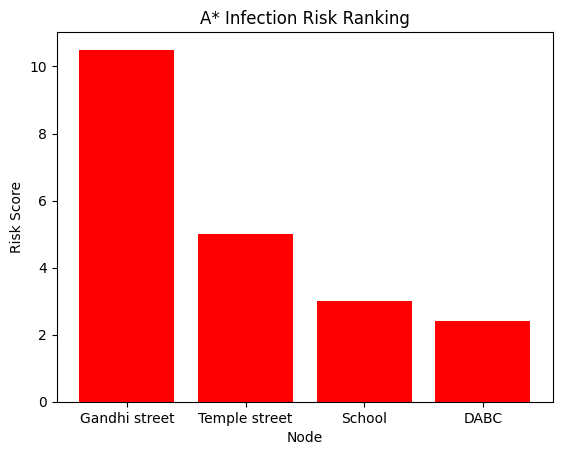

In [39]:
def heuristic(node):
    dens = G.nodes[node][DENS_COL]
    vacc = G.nodes[node][VACC_COL]
    return dens * (1 - vacc)

def astar_ranking(G, start):
    scores = {node: heuristic(node) for node in G.nodes() if node != start}
    return sorted(scores.items(), key=lambda x: -x[1])

astar_result = astar_ranking(G, start_node)
astar_df = pd.DataFrame(astar_result, columns=["Node", "Risk Score"])
print("A* Ranking (High Density + Low Vaccination → High Risk):")
display(astar_df)

# Plot
plt.bar(astar_df["Node"], astar_df["Risk Score"], color="red")
plt.title("A* Infection Risk Ranking")
plt.xlabel("Node")
plt.ylabel("Risk Score")
plt.show()

BFS vs A* Ranking Comparison:


,Node,Distance,Risk Score
0,DABC,2,2.4
1,Gandhi street,1,10.5
2,Market,0,0.0
3,School,1,3.0
4,Temple street,1,5.0


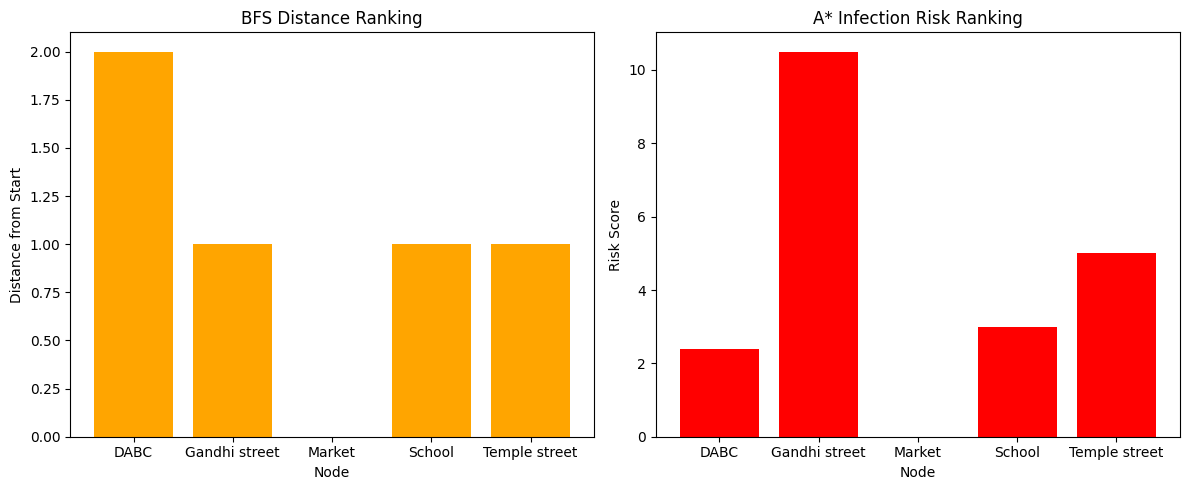

In [40]:
comparison_df = pd.merge(bfs_df, astar_df, on="Node", how="outer").fillna(0)
print("BFS vs A* Ranking Comparison:")
display(comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].bar(comparison_df["Node"], comparison_df["Distance"], color="orange")
axes[0].set_title("BFS Distance Ranking")
axes[0].set_xlabel("Node")
axes[0].set_ylabel("Distance from Start")

axes[1].bar(comparison_df["Node"], comparison_df["Risk Score"], color="red")
axes[1].set_title("A* Infection Risk Ranking")
axes[1].set_xlabel("Node")
axes[1].set_ylabel("Risk Score")

plt.tight_layout()
plt.show()

Enter infection intensity (0–1): 0.5
Enter number of Monte Carlo simulations: 1000
Running plain Monte Carlo...


,Node,Probability
0,School,0.700
1,Market,1.000
2,Gandhi street,0.734
3,Temple street,0.612
4,DABC,0.626


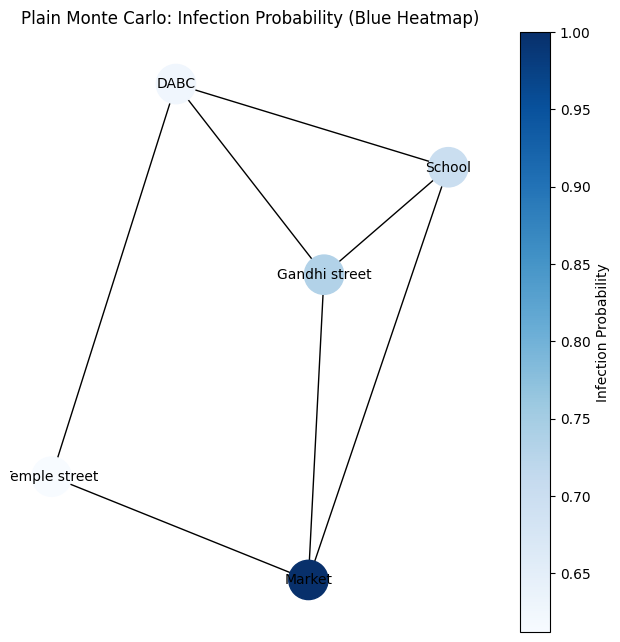

In [41]:
def monte_carlo_plain(G, start, intensity, runs):
    counts = {n: 0 for n in G.nodes()}
    for _ in range(runs):
        infected = set([start])
        frontier = [start]
        while frontier:
            new_frontier = []
            for node in frontier:
                for nb in G.neighbors(node):
                    if nb not in infected:
                        if random.random() < intensity:
                            infected.add(nb)
                            new_frontier.append(nb)
            frontier = new_frontier
        for n in infected:
            counts[n] += 1
    return {n: counts[n] / runs for n in G.nodes()}

intensity = float(input("Enter infection intensity (0–1): "))
runs = int(input("Enter number of Monte Carlo simulations: "))

print("Running plain Monte Carlo...")
mc_plain_result = monte_carlo_plain(G, start_node, intensity, runs)
mc_plain_df = pd.DataFrame(list(mc_plain_result.items()), columns=["Node", "Probability"])
display(mc_plain_df)

# Heatmap
plt.figure(figsize=(6,6))
pos = nx.spring_layout(G, seed=RNG_SEED)
vals = [mc_plain_result[n] for n in G.nodes()]
nodes = nx.draw(G, pos, with_labels=True, node_color=vals,
                cmap='Blues', node_size=800, font_size=10)

# Create colorbar properly
sm = plt.cm.ScalarMappable(cmap='Blues')
sm.set_array(vals)
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("Infection Probability")

plt.title("Plain Monte Carlo: Infection Probability (Blue Heatmap)")
plt.show()


Running biased Monte Carlo (BFS + A* integration)...


,Node,Probability
0,School,0.082
1,Market,1.000
2,Gandhi street,0.265
3,Temple street,0.119
4,DABC,0.012


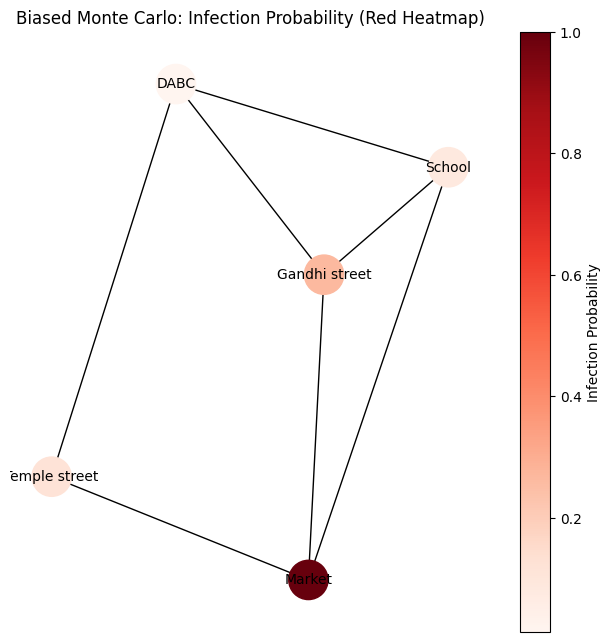

In [42]:
def monte_carlo_biased(G, start, intensity, runs, bfs_df, astar_df):
    bfs_weights = {r["Node"]: 1 / (r["Distance"] + 1) for _, r in bfs_df.iterrows()}
    astar_weights = {r["Node"]: r["Risk Score"] for _, r in astar_df.iterrows()}
    max_astar = max(astar_weights.values()) if astar_weights else 1

    counts = {n: 0 for n in G.nodes()}
    for _ in range(runs):
        infected = set([start])
        frontier = [start]
        while frontier:
            new_frontier = []
            for node in frontier:
                for nb in G.neighbors(node):
                    if nb not in infected:
                        prob = intensity * bfs_weights.get(nb, 0.1) * (astar_weights.get(nb, 0.1) / max_astar)
                        if random.random() < prob:
                            infected.add(nb)
                            new_frontier.append(nb)
            frontier = new_frontier
        for n in infected:
            counts[n] += 1
    return {n: counts[n] / runs for n in G.nodes()}

print("Running biased Monte Carlo (BFS + A* integration)...")
mc_biased_result = monte_carlo_biased(G, start_node, intensity, runs, bfs_df, astar_df)
mc_biased_df = pd.DataFrame(list(mc_biased_result.items()), columns=["Node", "Probability"])
display(mc_biased_df)

# Heatmap
# --- Fixed heatmap for biased Monte Carlo ---
plt.figure(figsize=(6,6))
pos = nx.spring_layout(G, seed=RNG_SEED)
vals_b = [mc_biased_result[n] for n in G.nodes()]

nodes = nx.draw(G, pos, with_labels=True, node_color=vals_b,
                cmap='Reds', node_size=800, font_size=10)

# Proper colorbar attachment
sm_b = plt.cm.ScalarMappable(cmap='Reds')
sm_b.set_array(vals_b)
cbar = plt.colorbar(sm_b, ax=plt.gca())
cbar.set_label("Infection Probability")

plt.title("Biased Monte Carlo: Infection Probability (Red Heatmap)")
plt.show()

Plain vs Biased Monte Carlo Comparison:


,Node,Probability_Plain,Probability_Biased
0,School,0.700,0.082
1,Market,1.000,1.000
2,Gandhi street,0.734,0.265
3,Temple street,0.612,0.119
4,DABC,0.626,0.012


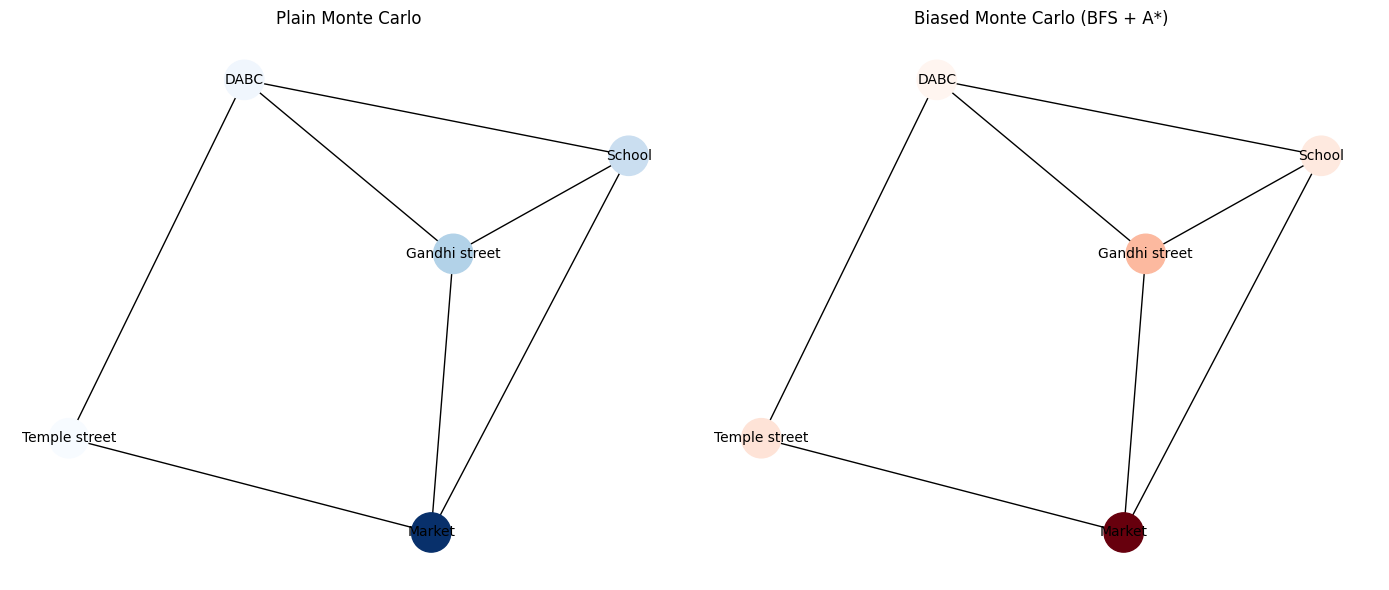

In [43]:
combined = pd.merge(mc_plain_df, mc_biased_df, on="Node", suffixes=("_Plain", "_Biased"))
print("Plain vs Biased Monte Carlo Comparison:")
display(combined)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Plain
nx.draw(G, pos, with_labels=True,
        node_color=[mc_plain_result[n] for n in G.nodes()],
        cmap='Blues', node_size=800, font_size=10, ax=axes[0])
axes[0].set_title("Plain Monte Carlo")

# Biased
nx.draw(G, pos, with_labels=True,
        node_color=[mc_biased_result[n] for n in G.nodes()],
        cmap='Reds', node_size=800, font_size=10, ax=axes[1])
axes[1].set_title("Biased Monte Carlo (BFS + A*)")

plt.tight_layout()
plt.show()